# Aula 03 - Modelos de Linguagem Clássicos

**Curso:** Processamento de Linguagem Natural  
**Aluno:** [Gisele Fonseca]  
**Data:** [19/01/2026]

## Instruções
1. Complete todos os exercícios marcados com `# === SEU CÓDIGO AQUI ===`
2. Execute as células de teste para verificar suas respostas
3. **Não modifique as células de teste**
4.  Execute todas as células em ordem
5.  Respostas devem ser armazenadas nas variáveis indicadas

## Critérios de Avaliação
- **Conteúdo (100%):** Testes automáticos

---

## Dataset

Utilizaremos o dataset **B2W-Reviews01** para treinar modelos de linguagem.

---

## Setup

In [1]:
# === CONFIGURAÇÃO INICIAL ===

!pip install --upgrade pip --quiet
!pip cache purge
!pip install otter-grader --no-cache-dir -q
!pip install nltk --quiet
!mkdir -p tests

print("Ambiente configurado!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.7 MB/s eta 0:00:00
Files removed: 6 (1.8 MB)
Ambiente configurado!


In [2]:
%%writefile tests/q1.py
OK_FORMAT = True

test = {
    "name": "q1",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(preparar_sentenca_lm), "Função preparar_sentenca_lm não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar tokens de início e fim
                    >>> resultado = preparar_sentenca_lm("teste")
                    >>> assert resultado[0] == '<s>', "Deve começar com <s>"
                    >>> assert resultado[-1] == '</s>', "Deve terminar com </s>"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar lowercase
                    >>> resultado = preparar_sentenca_lm("TESTE MAIÚSCULO")
                    >>> tokens_internos = resultado[1:-1]
                    >>> assert all(t == t.lower() for t in tokens_internos), "Tokens devem estar em minúsculas"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar remoção de não-alfabéticos
                    >>> resultado = preparar_sentenca_lm("teste 123 pontuação!")
                    >>> tokens_internos = resultado[1:-1]
                    >>> assert all(t.isalpha() for t in tokens_internos), "Deve conter apenas tokens alfabéticos"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q1.py


In [3]:
%%writefile tests/q2.py
OK_FORMAT = True

test = {
    "name": "q2",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar variáveis
                    >>> assert 'contagem_unigramas' in dir(), "Variável contagem_unigramas não foi criada"
                    >>> assert 'contagem_bigramas' in dir(), "Variável contagem_bigramas não foi criada"
                    >>> assert 'contagem_trigramas' in dir(), "Variável contagem_trigramas não foi criada"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> from collections import Counter
                    >>> # Verificar tipos
                    >>> assert isinstance(contagem_unigramas, Counter), "contagem_unigramas deve ser Counter"
                    >>> assert isinstance(contagem_bigramas, Counter), "contagem_bigramas deve ser Counter"
                    >>> assert isinstance(contagem_trigramas, Counter), "contagem_trigramas deve ser Counter"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar conteúdo
                    >>> assert len(contagem_unigramas) > 0, "contagem_unigramas não deve estar vazia"
                    >>> assert len(contagem_bigramas) > 0, "contagem_bigramas não deve estar vazia"
                    >>> assert len(contagem_trigramas) > 0, "contagem_trigramas não deve estar vazia"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar formato das chaves
                    >>> primeiro_uni = list(contagem_unigramas.keys())[0]
                    >>> primeiro_bi = list(contagem_bigramas.keys())[0]
                    >>> assert isinstance(primeiro_uni, tuple) and len(primeiro_uni) == 1, "Unigramas devem ser tuplas de 1 elemento"
                    >>> assert isinstance(primeiro_bi, tuple) and len(primeiro_bi) == 2, "Bigramas devem ser tuplas de 2 elementos"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q2.py


In [4]:
%%writefile tests/q3.py
OK_FORMAT = True

test = {
    "name": "q3",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(probabilidade_bigrama_mle), "Função probabilidade_bigrama_mle não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> resultado = probabilidade_bigrama_mle('produto', 'bom', contagem_bigramas, contagem_unigramas)
                    >>> assert isinstance(resultado, float), "Deve retornar float"
                    >>> assert 0 <= resultado <= 1, "Probabilidade deve estar entre 0 e 1"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar bigrama inexistente
                    >>> resultado = probabilidade_bigrama_mle('xyz', 'abc', contagem_bigramas, contagem_unigramas)
                    >>> assert resultado == 0.0, "Bigrama inexistente deve retornar 0"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q3.py


In [5]:
%%writefile tests/q4.py
OK_FORMAT = True

test = {
    "name": "q4",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(probabilidade_bigrama_add_k), "Função probabilidade_bigrama_add_k não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> resultado = probabilidade_bigrama_add_k('produto', 'bom', contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert isinstance(resultado, float), "Deve retornar float"
                    >>> assert resultado > 0, "Com suavização, probabilidade deve ser > 0"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar que suavização dá prob > 0 para bigramas inexistentes
                    >>> resultado = probabilidade_bigrama_add_k('xyz', 'abc', contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert resultado > 0, "Suavização deve dar probabilidade > 0"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q4.py


In [6]:
%%writefile tests/q5.py
OK_FORMAT = True

test = {
    "name": "q5",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(log_probabilidade_sentenca), "Função log_probabilidade_sentenca não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> sentenca_teste = ['<s>', 'produto', 'bom', '</s>']
                    >>> resultado = log_probabilidade_sentenca(sentenca_teste, contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert isinstance(resultado, float), "Deve retornar float"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Log prob deve ser negativo (prob < 1)
                    >>> sentenca_teste = ['<s>', 'produto', 'muito', 'bom', '</s>']
                    >>> resultado = log_probabilidade_sentenca(sentenca_teste, contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert resultado < 0, "Log-probabilidade deve ser negativa"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q5.py


In [7]:
%%writefile tests/q6.py
OK_FORMAT = True

test = {
    "name": "q6",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(calcular_perplexidade_corpus), "Função calcular_perplexidade_corpus não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> resultado = calcular_perplexidade_corpus(corpus_teste[:10], contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert isinstance(resultado, float), "Deve retornar float"
                    >>> assert resultado > 0, "Perplexidade deve ser positiva"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Perplexidade razoável (entre 1 e 10000)
                    >>> resultado = calcular_perplexidade_corpus(corpus_teste[:10], contagem_bigramas, contagem_unigramas, tamanho_vocab, k=0.1)
                    >>> assert 1 < resultado < 10000, "Perplexidade deve estar em range razoável"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q6.py


In [8]:
%%writefile tests/q7.py
OK_FORMAT = True

test = {
    "name": "q7",
    "points": 14,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar variáveis
                    >>> assert 'melhor_k' in dir(), "Variável melhor_k não foi criada"
                    >>> assert 'menor_perplexidade' in dir(), "Variável menor_perplexidade não foi criada"
                    >>> assert 'resultados_k' in dir(), "Variável resultados_k não foi criada"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar tipos
                    >>> assert isinstance(melhor_k, float), "melhor_k deve ser float"
                    >>> assert isinstance(menor_perplexidade, float), "menor_perplexidade deve ser float"
                    >>> assert isinstance(resultados_k, dict), "resultados_k deve ser dict"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar que melhor_k está nos valores testados
                    >>> valores_k_esperados = [0.001, 0.01, 0.1, 0.5, 1.0]
                    >>> assert melhor_k in valores_k_esperados, "melhor_k deve ser um dos valores testados"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar que menor_perplexidade é realmente a menor
                    >>> assert menor_perplexidade == min(resultados_k.values()), "menor_perplexidade deve ser a menor perplexidade"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q7.py


In [9]:
%%writefile tests/q8.py
OK_FORMAT = True

test = {
    "name": "q8",
    "points": 16,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(gerar_texto_modelo), "Função gerar_texto_modelo não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> resultado = gerar_texto_modelo(contagem_bigramas, max_tokens=10)
                    >>> assert isinstance(resultado, str), "Deve retornar string"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar que gera texto não vazio
                    >>> resultado = gerar_texto_modelo(contagem_bigramas, max_tokens=10)
                    >>> assert len(resultado) > 0, "Deve gerar texto não vazio"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar que não inclui tokens especiais no resultado
                    >>> resultado = gerar_texto_modelo(contagem_bigramas, max_tokens=10)
                    >>> assert '<s>' not in resultado, "Não deve incluir <s> no resultado"
                    >>> assert '</s>' not in resultado, "Não deve incluir </s> no resultado"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q8.py


In [10]:
# Imports e configurações
import otter
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk import ngrams

# Downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Configurações
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Seed para reprodutibilidade
random.seed(42)
np.random.seed(42)

# Inicializar grader
grader = otter.Notebook()

print("✓ Setup completo!")

✓ Setup completo!


## Carregar Dados

In [11]:
# Carregar dataset
url_dataset = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
df_reviews = pd.read_csv(url_dataset, nrows=1500)
df_reviews = df_reviews.dropna(subset=['review_text'])

print(f"Dataset carregado: {len(df_reviews)} reviews")

Dataset carregado: 1459 reviews


---

## Exercício 1: Preparação de Sentenças

Crie uma função `preparar_sentenca_lm` que prepara um texto para uso em modelo de linguagem:

1. Recebe um texto (string)
2. Tokeniza usando `word_tokenize` com language='portuguese'
3. Converte para minúsculas
4. Mantém apenas tokens alfabéticos
5. Adiciona `<s>` no início e `</s>` no fim
6. Retorna a lista de tokens

In [12]:
# === SEU CÓDIGO AQUI ===

def preparar_sentenca_lm(texto):
    tokens = word_tokenize(texto, language='portuguese')
    tokens = [t.lower() for t in tokens if t.isalpha()]
    return ['<s>'] + tokens + ['</s>']

In [13]:
grader.check("q1")

q1 results: All test cases passed!

---

## Exercício 2: Contagem de N-gramas

Usando a função `preparar_sentenca_lm`, prepare o corpus e conte n-gramas:

1. Prepare todas as reviews usando `preparar_sentenca_lm`
2. Filtre sentenças com menos de 4 tokens
3. Conte unigramas e armazene em `contagem_unigramas` (Counter)
4. Conte bigramas e armazene em `contagem_bigramas` (Counter)
5. Conte trigramas e armazene em `contagem_trigramas` (Counter)

**Dica:** Use `ngrams()` do NLTK.

In [14]:
# === SEU CÓDIGO AQUI ===

corpus_preparado = []
for texto in df_reviews['review_text']:
    sent = preparar_sentenca_lm(texto)
    if len(sent) >= 4:
        corpus_preparado.append(sent)

contagem_unigramas = Counter()
contagem_bigramas = Counter()
contagem_trigramas = Counter()

for sent in corpus_preparado:
    contagem_unigramas.update(list(ngrams(sent, 1)))
    contagem_bigramas.update(list(ngrams(sent, 2)))
    contagem_trigramas.update(list(ngrams(sent, 3)))

In [15]:
grader.check("q2")

q2 results: All test cases passed!

---

## Exercício 3: Probabilidade MLE

Crie uma função `probabilidade_bigrama_mle` que calcula P(w2|w1) usando MLE:

**Fórmula:** P(w2|w1) = C(w1, w2) / C(w1)

1. Recebe w1, w2, contagem_bigramas, contagem_unigramas
2. Retorna 0.0 se w1 não existir no corpus
3. Retorna a probabilidade calculada

In [16]:
# === SEU CÓDIGO AQUI ===

def probabilidade_bigrama_mle(w1, w2, bi_counts, uni_counts):
    c_w1 = uni_counts.get((w1,), 0)
    if c_w1 == 0:
        return 0.0
    return bi_counts.get((w1, w2), 0) / c_w1

In [17]:
grader.check("q3")

q3 results: All test cases passed!

### Preparação: Cálculo do Vocabulário

In [18]:
# Calcular tamanho do vocabulário (necessário para suavização)
vocabulario = set()
for sentenca in corpus_preparado:
    vocabulario.update(sentenca)
tamanho_vocab = len(vocabulario)

print(f"Tamanho do vocabulário: {tamanho_vocab}")

Tamanho do vocabulário: 4142


---

## Exercício 4: Suavização Add-k

Crie uma função `probabilidade_bigrama_add_k` que calcula P(w2|w1) com suavização:

**Fórmula:** P(w2|w1) = (C(w1, w2) + k) / (C(w1) + k * V)

Onde V é o tamanho do vocabulário.

1. Recebe w1, w2, bi_counts, uni_counts, V, k
2. Aplica a fórmula de suavização Add-k
3. Retorna a probabilidade

In [19]:
# === SEU CÓDIGO AQUI ===

def probabilidade_bigrama_add_k(w1, w2, bi_counts, uni_counts, V, k):
    c_w1_w2 = bi_counts.get((w1, w2), 0)
    c_w1 = uni_counts.get((w1,), 0)
    return (c_w1_w2 + k) / (c_w1 + k * V)

In [20]:
grader.check("q4")

q4 results: All test cases passed!

---

## Exercício 5: Log-Probabilidade de Sentença

Crie uma função `log_probabilidade_sentenca` que calcula a log-probabilidade (base 2) de uma sentença:

**Fórmula:** log P(s) = Σ log₂ P(wi|wi-1)

1. Recebe sentença (lista de tokens com `<s>` e `</s>`), bi_counts, uni_counts, V, k
2. Usa `probabilidade_bigrama_add_k` para cada bigrama
3. Soma as log-probabilidades (use `math.log2`)
4. Retorna a log-probabilidade total

In [21]:
# === SEU CÓDIGO AQUI ===

def log_probabilidade_sentenca(sentenca, bi_counts, uni_counts, V, k):
    log_prob = 0.0
    for i in range(1, len(sentenca)):
        w1, w2 = sentenca[i-1], sentenca[i]
        p = probabilidade_bigrama_add_k(w1, w2, bi_counts, uni_counts, V, k)
        log_prob += math.log2(p)
    return log_prob

In [22]:
grader.check("q5")

q5 results: All test cases passed!

### Preparação: Divisão Treino/Teste

In [23]:
# Dividir corpus em treino e teste
split_idx = int(0.8 * len(corpus_preparado))
corpus_treino = corpus_preparado[:split_idx]
corpus_teste = corpus_preparado[split_idx:]

print(f"Treino: {len(corpus_treino)} sentenças")
print(f"Teste: {len(corpus_teste)} sentenças")

Treino: 1165 sentenças
Teste: 292 sentenças


---

## Exercício 6: Cálculo de Perplexidade

Crie uma função `calcular_perplexidade_corpus` que calcula a perplexidade do modelo:

**Fórmula:** PP = 2^(-1/N × Σ log₂ P(wi|wi-1))

1. Recebe corpus_teste, bi_counts, uni_counts, V, k
2. Calcula a soma das log-probabilidades de todas as sentenças
3. Conta o total de tokens (para normalizar)
4. Calcula e retorna a perplexidade

In [24]:
# === SEU CÓDIGO AQUI ===

def calcular_perplexidade_corpus(corpus_teste, bi_counts, uni_counts, V, k):
    soma_log = 0.0
    N = 0

    for sent in corpus_teste:
        soma_log += log_probabilidade_sentenca(sent, bi_counts, uni_counts, V, k)
        N += len(sent) - 1  # número de bigramas

    return 2 ** (-soma_log / N)

In [25]:
grader.check("q6")

q6 results: All test cases passed!

---

## Exercício 7: Otimização do Parâmetro k

Encontre o melhor valor de k para minimizar a perplexidade:

1. Teste os valores k = [0.001, 0.01, 0.1, 0.5, 1.0]
2. Calcule a perplexidade para cada k usando `corpus_teste`
3. Armazene os resultados em `resultados_k` (dicionário {k: perplexidade})
4. Armazene o melhor k em `melhor_k`
5. Armazene a menor perplexidade em `menor_perplexidade`

In [26]:
# === SEU CÓDIGO AQUI ===

valores_k = [0.001, 0.01, 0.1, 0.5, 1.0]
resultados_k = {}

for k in valores_k:
    pp = calcular_perplexidade_corpus(corpus_teste, contagem_bigramas, contagem_unigramas, tamanho_vocab, k)
    resultados_k[k] = pp

melhor_k = min(resultados_k, key=resultados_k.get)
menor_perplexidade = resultados_k[melhor_k]

In [27]:
grader.check("q7")

q7 results: All test cases passed!

---

## Exercício 8: Geração de Texto

Crie uma função `gerar_texto_modelo` que gera texto usando o modelo de bigramas:

1. Comece com `<s>` como contexto
2. Para cada passo:
   - Encontre todos os bigramas que começam com a palavra atual
   - Amoste a próxima palavra proporcionalmente às frequências
   - Pare se gerar `</s>` ou atingir max_tokens
3. Retorne o texto gerado (string, sem `<s>` e `</s>`)

**Dica:** Use `random.choices()` com weights.

In [28]:
# === SEU CÓDIGO AQUI ===

def gerar_texto_modelo(bi_counts, max_tokens=20):
    palavra_atual = '<s>'
    resultado = []

    for _ in range(max_tokens):
        candidatos = []
        pesos = []

        for (w1, w2), count in bi_counts.items():
            if w1 == palavra_atual:
                candidatos.append(w2)
                pesos.append(count)

        if not candidatos:
            break

        proxima = random.choices(candidatos, weights=pesos, k=1)[0]

        if proxima == '</s>':
            break

        resultado.append(proxima)
        palavra_atual = proxima

    return ' '.join(resultado)

In [29]:
grader.check("q8")

q8 results: All test cases passed!

---

## Visualização Extra (Não avaliado)

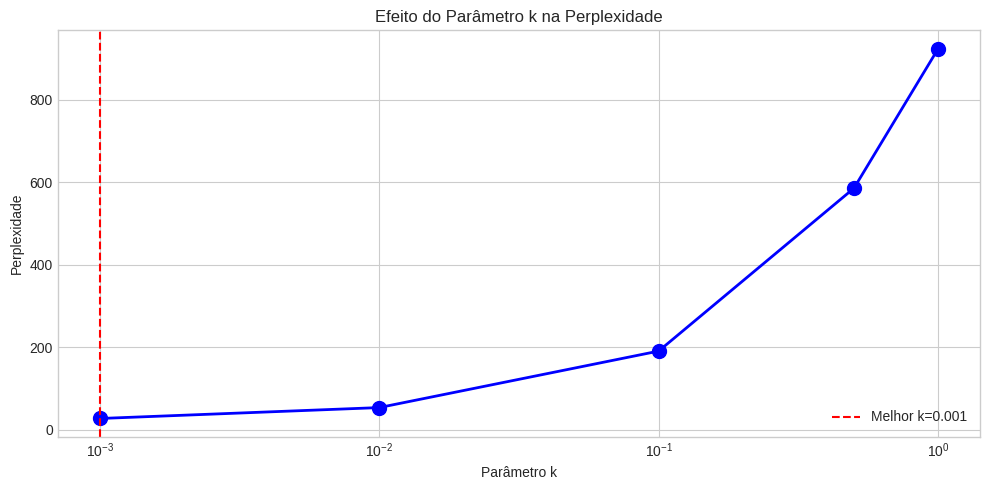

In [30]:
# Visualização da perplexidade por k
ks = list(resultados_k.keys())
pps = list(resultados_k.values())

plt.figure(figsize=(10, 5))
plt.plot(ks, pps, 'bo-', linewidth=2, markersize=10)
plt.axvline(x=melhor_k, color='r', linestyle='--', label=f'Melhor k={melhor_k}')
plt.xlabel('Parâmetro k')
plt.ylabel('Perplexidade')
plt.title('Efeito do Parâmetro k na Perplexidade')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

**Certifique-se de que todos os testes passaram antes de submeter.**